<a href="https://colab.research.google.com/github/dwninii/diabetes_risk_prediction_in_women/blob/main/Diabetes_In_Women_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Assessing Multivariable Predictors in Diabetes Risk Prediction

By: Niharika Dwivedi

## Introduction

Diabetes is a chronic condition with significant health implications, impacting millions of people worldwide. Early identification and effective risk prediction are crucial for managing and preventing diabetes-related complications such as cardiovascular disease, kidney failure, and neuropathy (Gale & Gillespie, n.d.). When modelling data, selecting the right set of predictors can greatly influence the accuracy and interpretability of the risk assessment. This study aims to explore the impact of incorporating multiple predictors on diabetes risk prediction by comparing the performance of a multiple linear regression model with age, BMI, and family history against a simpler model using only blood pressure as a predictor. By examining the addition of these variables, I seek to understand whether they contribute meaningful improvements in predicting diabetes risk and how these insights can better inform healthcare strategies for early intervention and prevention.

## Data Description

This dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases and aims to predict the likelihood of diabetes in patients based on various diagnostic measurements. Sourced from Kaggle, the dataset comprises nine variables and includes data exclusively from female patients who are at least 21 years old and of Pima Indian descent.



**Variables:**

| Index | Column                     | Description                                      | Type of Variable | Number of Observations | Typical Range/Values                          |
|-------|---------------------------|--------------------------------------------------|-------------------|------------------------|----------------------------------------------|
| 1     | Pregnancies               | To express the number of pregnancies             | Quantitative (Discrete)        | 768        | 0 to 10+ (10+ is less common)                |
| 2     | Glucose                   | To express the glucose level in blood            | Quantitative (Continuous)         | 768        | Fasting: 70-126 mg/dL; Postprandial: <140 to ≥200 mg/dL |
| 3     | BloodPressure             | To express the blood pressure measurement         | Quantitative (Continuous)          | 768        | Systolic: <120 to ≥140 mmHg; Diastolic: <80 to ≥100 mmHg |
| 4     | SkinThickness             | To express the thickness of the skin             | Quantitative (Continuous)          | 768        | Men: 12-23 mm; Women: 16-30 mm              |
| 5     | Insulin                   | To express the insulin level in blood            | Quantitative (Continuous)          | 768       | Fasting: 2-25 µIU/mL ;  Higher levels might indicate insulin resistance or type 2 diabetes.                        |
| 6     | BMI                       | To express the body mass index                   | Quantitative (Continuous)          | 768        | Underweight: <18.5; Normal: 18.5-24.9; Overweight: 25-29.9; Obesity: ≥30 |
| 7     | DiabetesPedigreeFunction  | To express the diabetes percentage                | Quantitative (Continuous)          | 768       | 0 to 2.5 (higher indicates stronger predisposition) |
| 8     | Age                       | To express the age                               | Quantitative (Discrete)          | 768        | 21-100             |
| 9     | Outcome                   | To express the final result (1 is Yes, 0 is No) | Qualitative (Binary)       | 768        | 0 or 1                                       |


## Question

The question I will be analyzing:

*How does the addition of age, BMI, and family history as predictors in a multiple logistic regression model improve the prediction of diabetes risk compared to a single logistic regression model using only blood pressure?*


**Input Variables (Explanatory Variables):**

- `Age`
- `BMI`
- Diabetes Pedigree Function (`DiabetesPedigreeFunction`): This variable represents the genetic risk of diabetes, which can help improve the predictive power of your model.
- `BloodPressure` (Blood Pressure): This variable is used in both the single logistic regression model and the multiple logistic regression model

The listed input variables are all continuous numerical variables.

**Response Variable:**

- Diabetes Diagnosis (`Outcome`): This indicates whether the individual has been diagnosed with diabetes (1 for positive diagnosis, 0 for negative).

The response variable is a binary categorical variable.



In [ ]:
library(dplyr)
library(ggplot2)
install.packages("corrplot")
library(corrplot)
install.packages("reshape2")
library(reshape2)
library(RColorBrewer)
library(tidyverse)
library(MASS)
install.packages("glmnet")
library(glmnet)
install.packages("pROC")
library(pROC)
install.packages("caret")
library(caret)
install.packages("httr")
library(httr)
install.packages("broom")
library(broom)
install.packages("regclass")
library(regclass)
install.packages("car")
library(car)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    

In [ ]:


#diabetes_data <- read.csv("/content/diabetes.csv")

dataset_url <- "https://www.kaggle.com/api/v1/datasets/download/whenamancodes/predict-diabities"

response <- GET(dataset_url)

temp_file <- tempfile(fileext = ".csv")
writeBin(content(response), temp_file)

diabetes_data <- read_csv(temp_file)

head(diabetes_data)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
5,116,74,0,0,25.6,0.201,30,0


In [ ]:


summary(diabetes_data)
str(diabetes_data)

# Check for missing values
sum(is.na(diabetes_data))


  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
    Insulin           BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.0   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.0   1st Qu.:27.30   1st Qu.:0.2437           1st Qu.:24.00  
 Median : 30.5   Median :32.00   Median :0.3725           Median :29.00  
 Mean   : 79.8   Mean   :31.99   Mean   :0.4719           Mean   :33.24  
 3rd Qu.:127.2   3rd Qu.:36.60   3rd Qu.:0.6262           3rd Qu.:41.00  
 Max.   :846.0   Max.   :67.10   Max.   :2.4200           Max.   :81.00  
    Outcome  

spc_tbl_ [768 × 9] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Pregnancies             : num [1:768] 6 1 8 1 0 5 3 10 2 8 ...
 $ Glucose                 : num [1:768] 148 85 183 89 137 116 78 115 197 125 ...
 $ BloodPressure           : num [1:768] 72 66 64 66 40 74 50 0 70 96 ...
 $ SkinThickness           : num [1:768] 35 29 0 23 35 0 32 0 45 0 ...
 $ Insulin                 : num [1:768] 0 0 0 94 168 0 88 0 543 0 ...
 $ BMI                     : num [1:768] 33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ DiabetesPedigreeFunction: num [1:768] 0.627 0.351 0.672 0.167 2.288 ...
 $ Age                     : num [1:768] 50 31 32 21 33 30 26 29 53 54 ...
 $ Outcome                 : num [1:768] 1 0 1 0 1 0 1 0 1 1 ...
 - attr(*, "spec")=
  .. cols(
  ..   Pregnancies = col_double(),
  ..   Glucose = col_double(),
  ..   BloodPressure = col_double(),
  ..   SkinThickness = col_double(),
  ..   Insulin = col_double(),
  ..   BMI = col_double(),
  ..   DiabetesPedigreeFunction = col_doubl

[1] 0

In [ ]:

tidy_data <- diabetes_data %>%
  dplyr::select(Pregnancies, Age, BMI, DiabetesPedigreeFunction, Outcome, BloodPressure) %>%
  filter(DiabetesPedigreeFunction > 0) %>%
  filter_all(all_vars(!is.na(.)))
head(tidy_data)

Pregnancies,Age,BMI,DiabetesPedigreeFunction,Outcome,BloodPressure
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,50,33.6,0.627,1,72
1,31,26.6,0.351,0,66
8,32,23.3,0.672,1,64
1,21,28.1,0.167,0,66
0,33,43.1,2.288,1,40
5,30,25.6,0.201,0,74


## Exploratory Data Analysis and Visualization¶

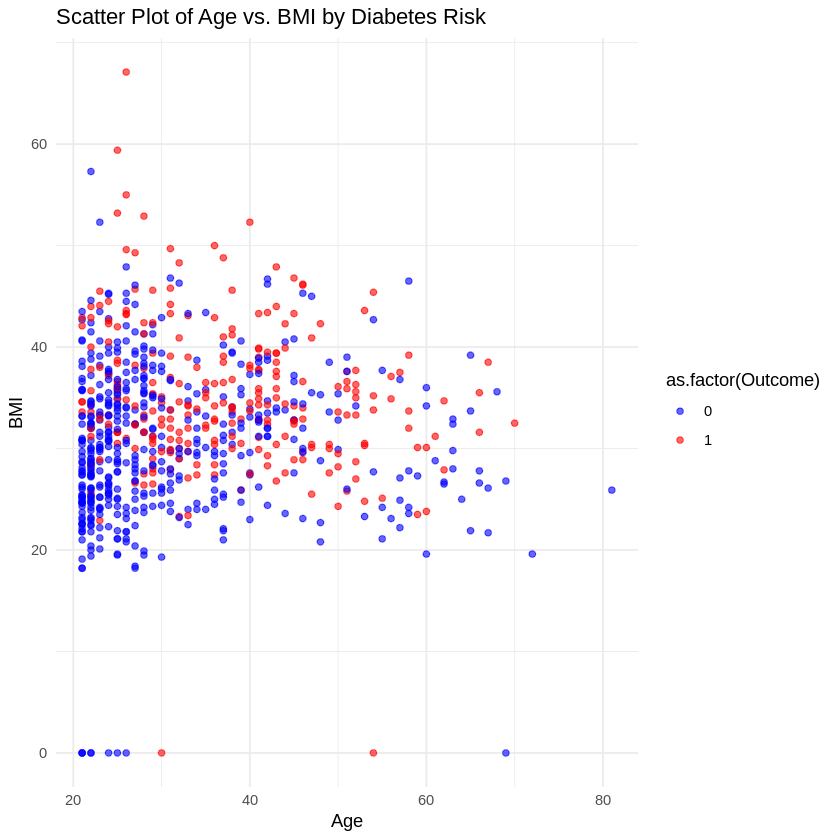

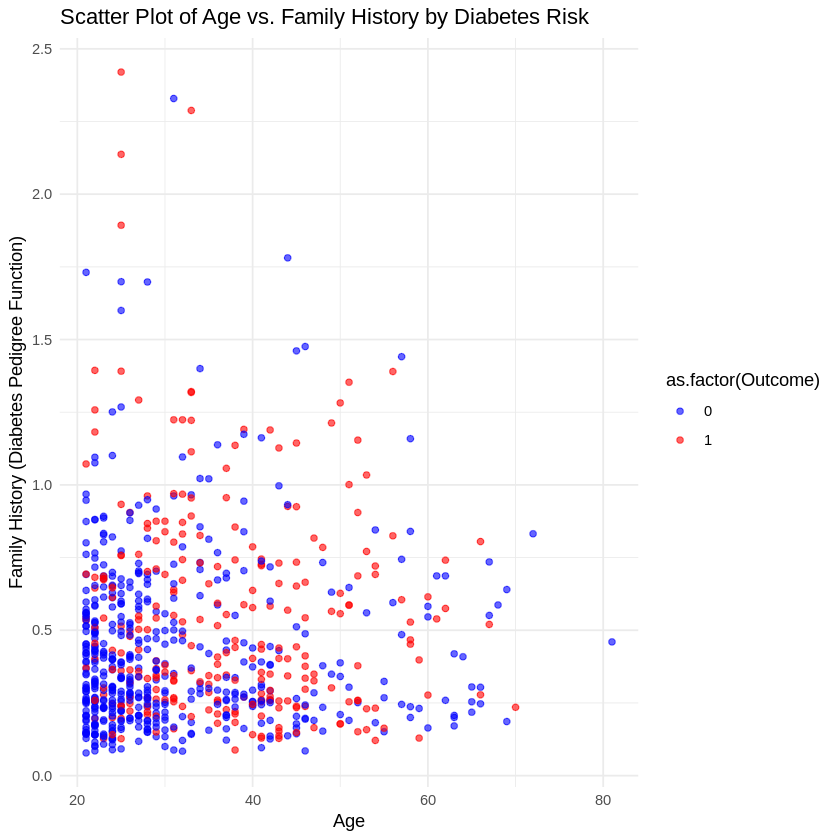

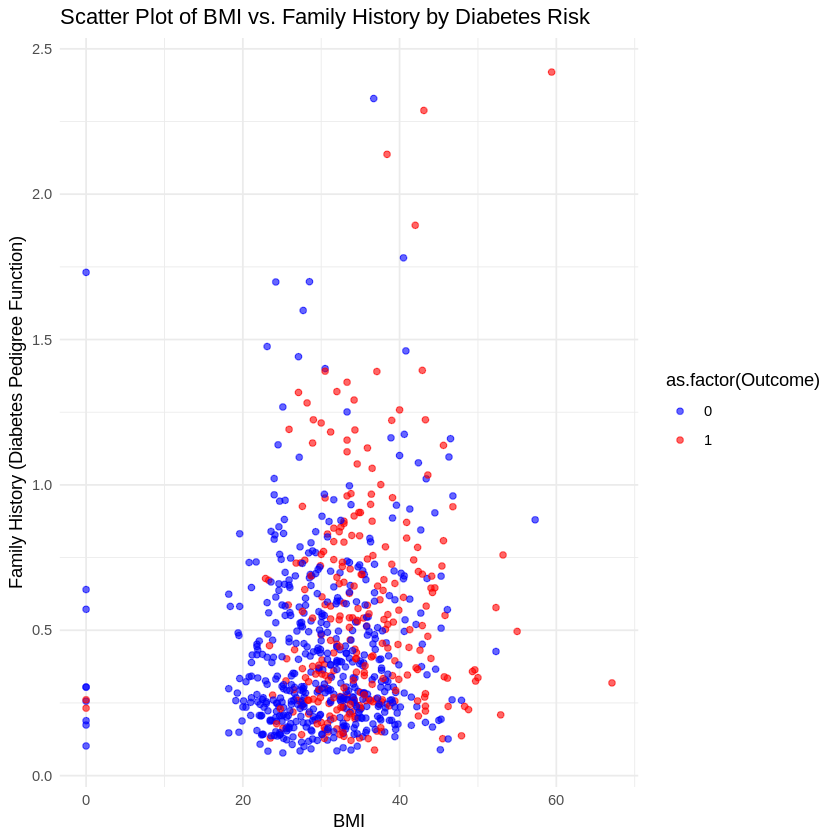

In [ ]:
# Initial EDA - This code performs initial exploratory data analysis (EDA)
# by visualizing relationships between predictor variables and the diabetes outcome,
# checking distributions, and identifying correlations and outliers.


ggplot(data = tidy_data, aes(x = Age, y = BMI, color = as.factor(Outcome))) +
  geom_point(alpha = 0.6) +  # Adjust alpha for better visibility
  labs(title = "Scatter Plot of Age vs. BMI by Diabetes Risk",
       x = "Age",
       y = "BMI") +
  scale_color_manual(values = c("0" = "blue", "1" = "red")) +  # Customize color scheme
  theme_minimal()

ggplot(data = tidy_data, aes(x = Age, y = DiabetesPedigreeFunction, color = as.factor(Outcome))) +
  geom_point(alpha = 0.6) +
  labs(title = "Scatter Plot of Age vs. Family History by Diabetes Risk",
       x = "Age",
       y = "Family History (Diabetes Pedigree Function)") +
  scale_color_manual(values = c("0" = "blue", "1" = "red")) +
  theme_minimal()

ggplot(data = tidy_data, aes(x = BMI, y = DiabetesPedigreeFunction, color = as.factor(Outcome))) +
  geom_point(alpha = 0.6) +
  labs(title = "Scatter Plot of BMI vs. Family History by Diabetes Risk",
       x = "BMI",
       y = "Family History (Diabetes Pedigree Function)") +
  scale_color_manual(values = c("0" = "blue", "1" = "red")) +
  theme_minimal()


In [ ]:

cat("The correlation coefficient between Age and BMI is:", cor(tidy_data$Age, tidy_data$BMI))
cat("\nThe correlation coefficient between Age and Family History is:", cor(tidy_data$Age, tidy_data$DiabetesPedigreeFunction))
cat("\nThe correlation coefficient between BMI and Family History is:", cor(tidy_data$BMI, tidy_data$DiabetesPedigreeFunction))

The correlation coefficient between Age and BMI is: 0.03624187
The correlation coefficient between Age and Family History is: 0.03356131
The correlation coefficient between BMI and Family History is: 0.140647

### Interpretation of Scatterplots

1. Scatter Plot of `Age` vs. `BMI` by Diabetes Risk

This plot examines the relationship between Age and BMI for individuals with and without diabetes. Points are colored based on the diabetes outcome, where blue represents non-diabetic (Outcome = 0) and red represents diabetic (Outcome = 1). It provides a visual sense of whether diabetes risk is associated with higher BMI or age. As we can see, the scatter plot depicts that the average body mass index (BMI) for women is around 30 which accurately represents currents statistics of women in the United States having a BMI of 29.8. With a correlation coefficient of 0.03624187 between Age and BMI, we find a very weak positive relationship between the two variables, which can be observed in the scatterplot.

2. Scatter Plot of  `Age` vs. `Family History` by Diabetes Risk

This graph shows the relationship between Age and Diabetes Pedigree Function (a measure of family history of diabetes), with colors differentiating diabetes outcomes. It helps explore whether family history interacts with age to affect diabetes risk, potentially revealing clusters or trends among diabetic and non-diabetic individuals. With a correlation coefficient of 0.03356131 between Age and Family History, we find another very weak positive relationsihp between the two variables. As observed in the plot, there is no major observable relationship between Age and Family History.

From the plot, we can observe:

- Most individuals, regardless of diabetes outcome, have lower Diabetes Pedigree Function values (below 1.0).
- Younger individuals (around 20-40 years) tend to cluster at lower family history values, especially for those without diabetes.
- There is a slight spread of higher Diabetes Pedigree Function values among diabetic individuals (red points), suggesting a potential association between stronger family history and diabetes risk.


3. Scatter Plot of  `BMI` vs. `Family History` by Diabetes Risk

This scatter plot visualizes the relationship between BMI (Body Mass Index) and Diabetes Pedigree Function (family history of diabetes), with points colored by diabetes outcome. Blue points represent individuals without diabetes (Outcome = 0), and red points represent individuals with diabetes (Outcome = 1).

From the plot, we can observe:

- Most data points cluster in the BMI range of 20–40 and Diabetes Pedigree Function values below 1.0, regardless of outcome.
- There are more red points (diabetic individuals) appearing at higher BMI values, suggesting a possible association between higher BMI and diabetes risk.
- Individuals with very high family history values (above 1.5) appear predominantly in the diabetic group, indicating a potential link between a strong family history and diabetes.

Additionally, with a correlation coefficient of 0.140647 between BMI and Family History, there is weak positive relationship between the two variables.

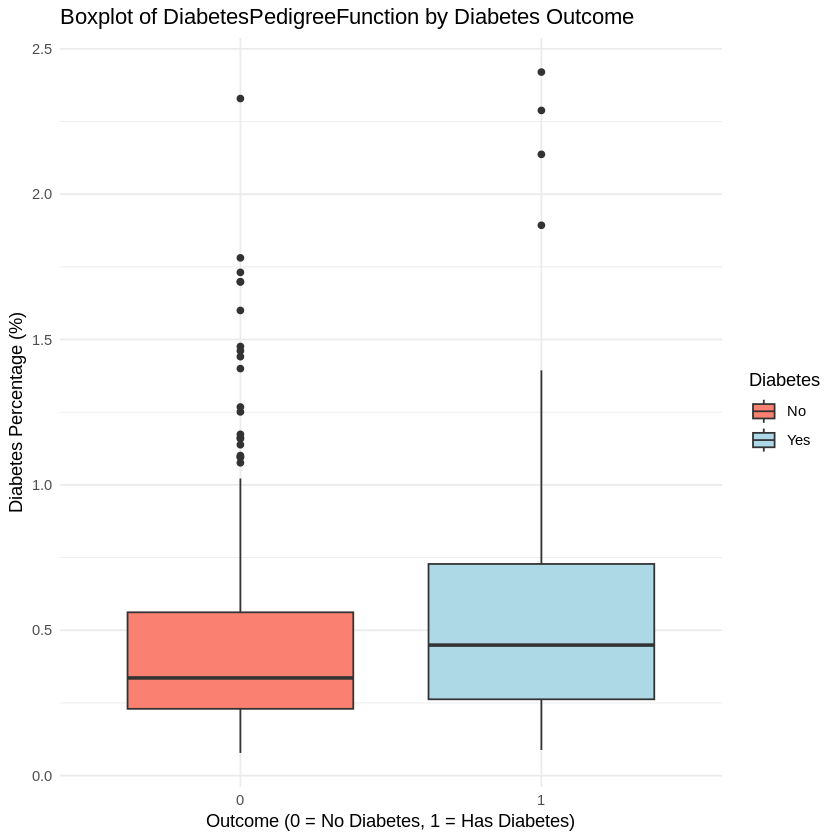

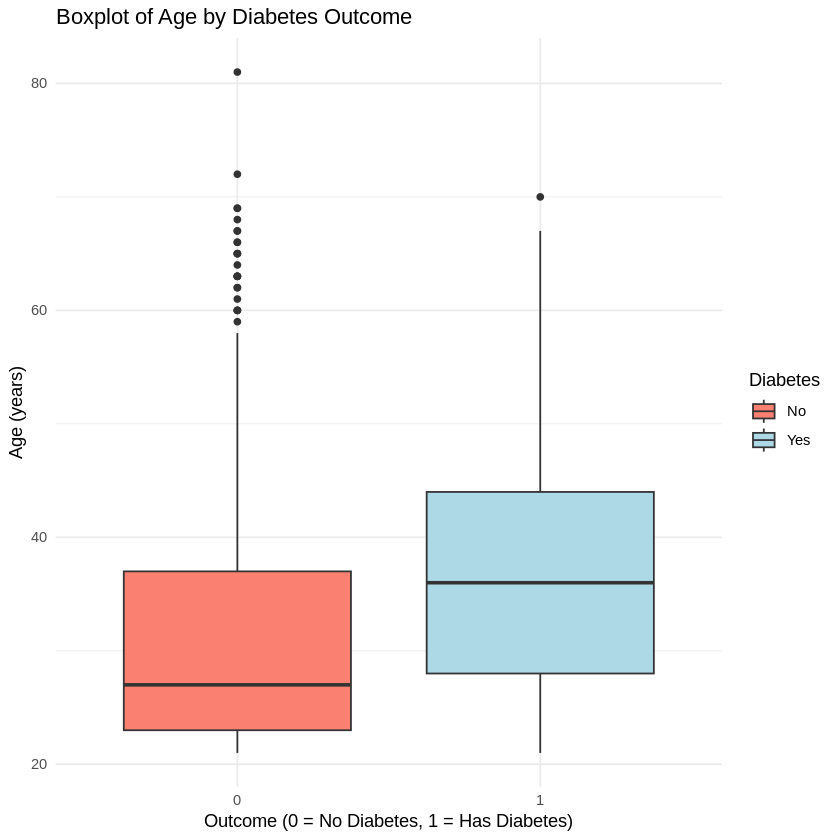

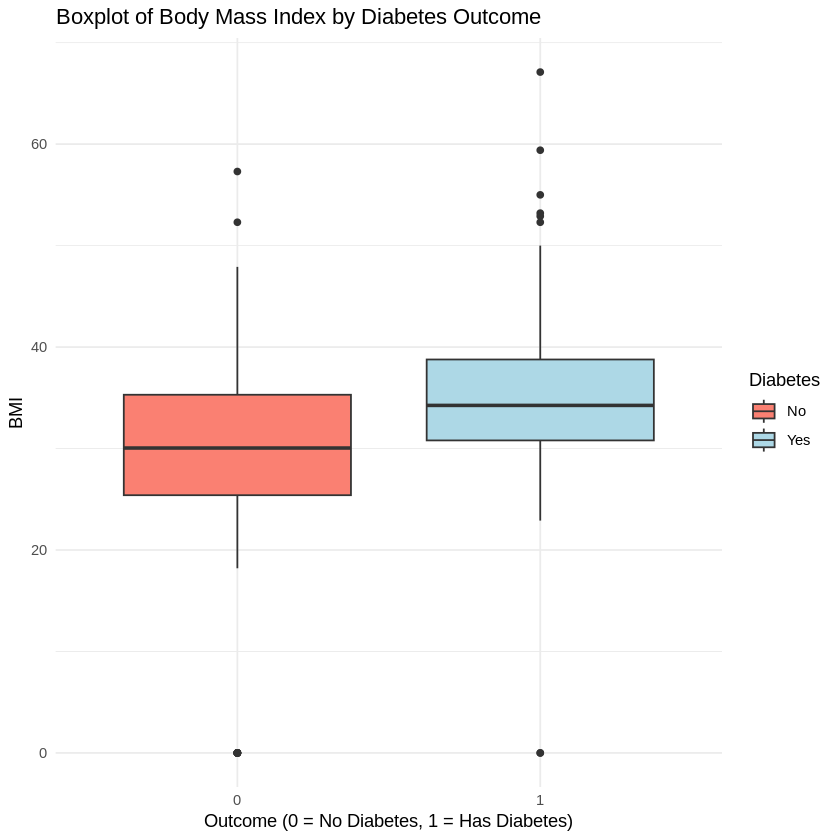

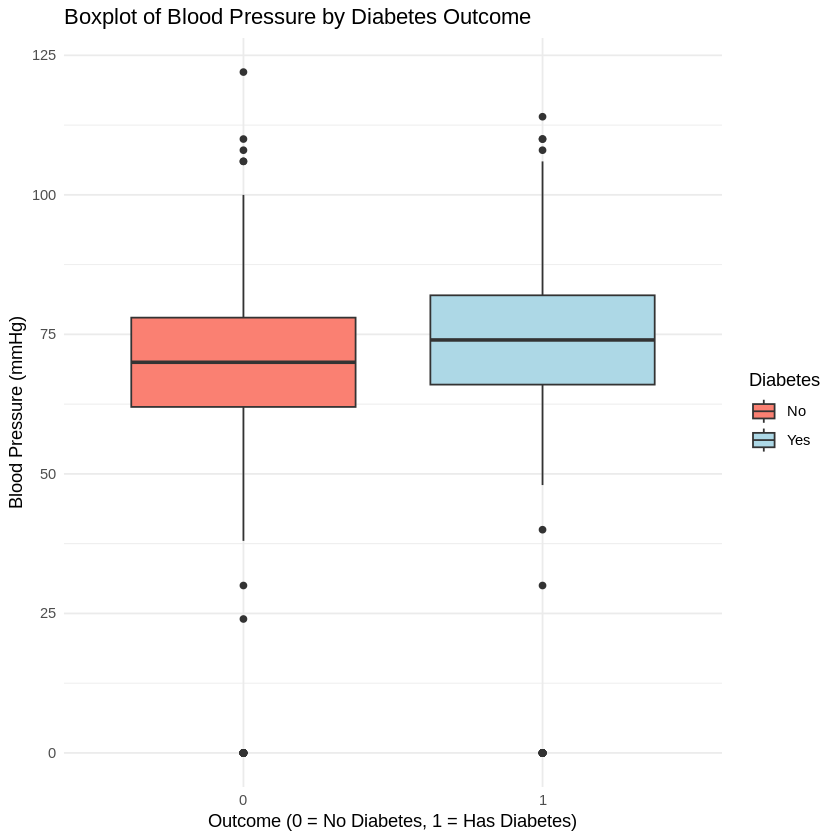

In [ ]:
# EDA 2 - Boxplot between the independent variables and the dependent variables
# (Outcome).


diabetes_bp <- ggplot(tidy_data, aes(x = factor(Outcome),
                                     y = DiabetesPedigreeFunction,
        fill = factor(Outcome))) +
        geom_boxplot() +
        labs(title = "Boxplot of DiabetesPedigreeFunction by Diabetes Outcome",
            x = "Outcome (0 = No Diabetes, 1 = Has Diabetes)",
            y = "Diabetes Percentage (%)",
            fill = "Diabetes") +
        theme_minimal() +
        scale_fill_manual(values = c("0" = "salmon", "1" = "lightblue"),
                          labels = c("No", "Yes"))

age_bp <- ggplot(tidy_data, aes(x = factor(Outcome), y = Age,
      fill = factor(Outcome))) +
      geom_boxplot() +
      labs(title = "Boxplot of Age by Diabetes Outcome",
          x = "Outcome (0 = No Diabetes, 1 = Has Diabetes)",
          y = "Age (years)",
          fill = "Diabetes") +
      theme_minimal() +
      scale_fill_manual(values = c("0" = "salmon", "1" = "lightblue"),
                        labels = c("No", "Yes"))

bmi_bp <- ggplot(tidy_data, aes(x = factor(Outcome), y = BMI,
      fill = factor(Outcome))) +
      geom_boxplot() +
      labs(title = "Boxplot of Body Mass Index by Diabetes Outcome",
          x = "Outcome (0 = No Diabetes, 1 = Has Diabetes)",
          y = "BMI",
          fill = "Diabetes") +
      theme_minimal() +
      scale_fill_manual(values = c("0" = "salmon", "1" = "lightblue"),
                        labels = c("No", "Yes"))

bloodpres_bp <- ggplot(tidy_data, aes(x = factor(Outcome), y = BloodPressure,
      fill = factor(Outcome))) +
      geom_boxplot() +
      labs(title = "Boxplot of Blood Pressure by Diabetes Outcome",
          x = "Outcome (0 = No Diabetes, 1 = Has Diabetes)",
          y = "Blood Pressure (mmHg)",
          fill = "Diabetes") +
      theme_minimal() +
      scale_fill_manual(values = c("0" = "salmon", "1" = "lightblue"),
                        labels = c("No", "Yes"))

diabetes_bp
age_bp
bmi_bp
bloodpres_bp

### Interpretation of Boxplots.
- `DiabetesPedigreeFunction` vs `Outcome`
> The median `DiabetesPedigreeFunction` is higher in individuals with diabetes, suggesting a stronger family tendency towards diabetes in this group. There are more outliers in the "Has Diabetes" group, indicating some individuals with a significantly high `DiabetesPedigreeFunction`.


- `Age` vs `Outcome`
> Individuals with diabetes tend to be older on average compared to those without diabetes. Then, the median age for individuals with diabetes is higher, and the interquartile range (IQR) is also broader, suggesting more variability in age among this group. Both groups have some outliers, with the "No Diabetes" group having younger outliers and the "Has Diabetes" group showing older outliers.

- `BMI` vs `Outcome`
> The median BMI is higher for individuals with diabetes than for those without, suggesting a correlation between higher BMI and diabetes. The spread of BMI values (IQR) is similar for both groups, though there are more extreme high outliers in the "Has Diabetes" group.


- `BloodPressure` vs `Outcome`
> Blood pressure levels are slightly higher on average for individuals with diabetes compared to those without, though the difference is not as pronounced as in the age variable. The IQR for both groups is similar, indicating comparable variability. Outliers are present in both groups, with some individuals having significantly higher or lower blood pressure levels.

`Age` and `BMI` show noticeable differences between individuals with (1) and without diabetes (0), with those having diabetes generally being older and having higher `BMI`. `BloodPressure` differences are less significant but still slightly higher in individuals with diabetes. `DiabetesPedigreeFunction` highlights individuals with diabetes having higher median values and more outliers. ⁠Overall, these boxplots suggest that `Age`, `BMI`, and `DiabetesPedigreeFunction` are stronger indicators of diabetes, while `BloodPressure` shows less of a distinct relationship.

##Methods: Plan

The report utilizes data provided by the National Institute of Diabetes and Digestive and Kidney Diseases, which provides a reliable source of data for analyzing the potential variables associated with diabetes. Our objective is comparing multiple logistic regression using BMI, blood pressure, age, and family history as independent variables to a single logistic regression using blood pressure as the independent variable, in which both models are designed to predict the presence of diabetes. To check for independence, we compute the number of total observations in addition to the number of patients by outcome:

In [ ]:

# Number of observations
observations = tidy_data |>
    nrow()
cat("There are", observations, "observations.")
diabetes_positive = tidy_data |>
    filter(Outcome == 1) |>
    nrow()

cat("\nThere are", diabetes_positive, "patients with diabetes.")
cat("\nThere are", observations - diabetes_positive, "patients without diabetes.")

There are 768 observations.
There are 268 patients with diabetes.
There are 500 patients without diabetes.

We are using data that has been randomly sampled with 768 observations total, including 268 with diabetes and 500 without diabetes. We know that the data is independent because there are far more than 2680 females over 21 with Pima Indian heritage that have diabetes. We can also check for multicollinearity between independent variables before we proceed with any testing:

In [ ]:

# Computing the multicollinearity in the independent variables
VIF <- tidy(vif(glm(Outcome ~ BloodPressure + Age + BMI + DiabetesPedigreeFunction, data = tidy_data, family = binomial)))

names(VIF)[1] <- "variable"
names(VIF)[2] <- "VIF"

VIF

Warning message in tidy.numeric(vif(glm(Outcome ~ BloodPressure + Age + BMI + DiabetesPedigreeFunction, :
“'tidy.numeric' is deprecated.
See help("Deprecated")”


variable,VIF
<chr>,<dbl>
BloodPressure,1.126885
Age,1.097156
BMI,1.087085
DiabetesPedigreeFunction,1.002688


With a low VIF for each independent variable, we can conduct our methods on the data as multicollinearity is unlikely.

### Inferential Approach

The data is randomly sampled, the data is independent, the sample size is large enough, and there is no major multicollinearity in the independent variables. Thus, I will use a likelihood ratio test on the two models to test if adding BMI, age, and family history to a model that predicts the presence of diabetes with a patient’s blood pressure makes our model significantly more accurate. Using a likelihood ratio test is appropriate for this case since I am testing the goodness of fit of two nested models, in which the more complex model has the same dependent and independent variables as the simple model, as well as additional independent variables. Additionally, I want to start by evaluating if the additional independent variables collectively explain a significant amount of variance in the outcome before asking further questions about specific variables, so the likelihood ratio test is an important first step to take before I decide to conduct any further analysis. The null hypothesis is that the single logistic regression model provides as a good fit for the data as the multiple logistic regression model while the alternative hypothesis is that the multiple logistic regression model provides a significantly better fit to the data than the single logistic regression model. I will use a significance level of  $\alpha = 0.05$ for this test.

While the likelihood ratio test is appropriate for comparing nested models, it has potential limitations. One limitation is that multicollinearity may appear minimal based on correlations but the observed high VIF values may still inflate standard errors and create unreliable parameter estimates in the multiple logistic regression model. Additionally, the test only evaluates overall model improvement and doesn’t identify specific predictors’ contribution. Considering these limitations, it’s important to not solely rely on this test when making conclusions about the data.

We will conduct a likelihood ratio test between the following two models at a signifincance level of $\alpha = 0.05$:

**Model 1:**
- Dependent variable: `Diabetes`
- Indepdent variable: `BloodPressure`
  
**Model 2:**
- Dependent variable: `Diabetes`
- Independent variables: `BloodPressure`, `BMI`, `Age`, `DiabetesPedigreeFunction`

In [ ]:

# Fit Model 1: Single predictor
model1 <- glm(Outcome ~ BloodPressure, data = tidy_data, family = binomial)

# Fit Model 2: Multiple predictors
model2 <- glm(Outcome ~ BloodPressure + Age + BMI + DiabetesPedigreeFunction, data = tidy_data, family = binomial)

# Perform the Likelihood Ratio Test
lrt <- tidy(anova(model1, model2, test = "Chisq"), exponentiate = TRUE) |>
    mutate(model = c("Model 1", "Model 2"))
lrt

term,df.residual,residual.deviance,df,deviance,p.value,model
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Outcome ~ BloodPressure,766,990.1276,NA,NA,NA,Model 1
Outcome ~ BloodPressure + Age + BMI + DiabetesPedigreeFunction,763,858.3643,3,131.7632,2.254612e-28,Model 2


We have obtained a p-value of $p = 2.254612*10^{-28}$ for the likelihood ratio test between the nested models. Therefore, at a signifiance level of $\alpha = 0.05$, we reject the null hypothesis that the single logistic regression model (Model 1) provides as good as a fit for the data as the multiple logistic regression model (Model 2). Under this test, can also conclude that the additional predictors in Model 2 significantly improve the performance of Model 1. It is also important to test which predictors improve the model's performance. We will test the significance of each predictor in Model 2 as follows:

In [ ]:


# Tests if p-values are less than 0.05
isSignificant = tidy(model2, exponentiate = TRUE) |>
    mutate(significant = ifelse(p.value < 0.05, "Yes", "No"))

isSignificant

term,estimate,std.error,statistic,p.value,significant
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),0.004529743,0.556604723,-9.696450,3.121708e-22,Yes
BloodPressure,0.991002098,0.004741588,-1.906245,5.661846e-02,No
Age,1.050407950,0.007287545,6.748310,1.495771e-11,Yes
BMI,1.105098518,0.013053741,7.655620,1.923813e-14,Yes
DiabetesPedigreeFunction,2.517249623,0.255513042,3.612993,3.026826e-04,Yes


We find that `Age`, `BMI`, and `DiabetesPedigreeFunction` all have a p-value that is less than $\alpha = 0.05$. Therefore, at this significance level, `Age`, `BMI`, and `DiabetesPedigreeFunction` each have a significant association with `Diabetes`.

Since the p-value of `BloodPressure` is greater than $\alpha = 0.05$, we find that `BloodPressure` does not have a statistically significant association with `Diabetes` at this significance level.

### Predictive Approach

The ROC (Receiver Operating Characteristic) curve is appropriate for our analysis because the assumptions of logistic regression, such as a binary outcome and linearity between predictors and log-odds, are met in our dataset. ROC provides a visual measure of a model's classification performance by plotting the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity). The Area Under the Curve (AUC) quantifies the model's discriminative ability; an AUC closer to 1.0 indicates excellent predictive accuracy, while an AUC around 0.5 suggests random guessing. Thus, ROC allows us to assess how well the model differentiates between positive and negative outcomes, helping decide if the model’s results are meaningful.

The first step was to split the dataset into training and testing sets to evaluate model performance consistently and avoid overfitting. We used the caret package to randomly partition the dataset into a 70% training set and a 30% test set, maintaining reproducibility by setting a seed.

In [ ]:

# Split the dataset into training and test sets
set.seed(123)  # For reproducibility
trainIndex <- createDataPartition(tidy_data$Outcome, p = 0.7, list = FALSE)
train_data <- tidy_data[trainIndex, ]
test_data <- tidy_data[-trainIndex, ]

We are using Model 1 (single logistic regression model) and Model 2 (multiple logistic regression model) again from the inferential approach.

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



[1] "AUC for Simple Model: 0.55"
[1] "AUC for Multiple Model: 0.74"


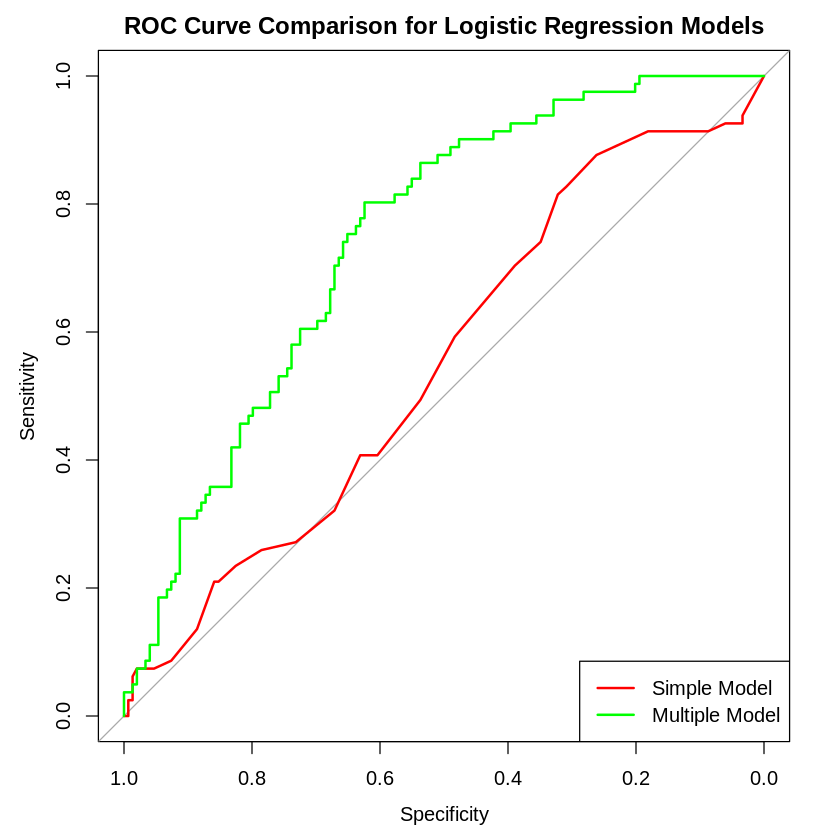

In [ ]:


# Fit a simple logistic regression model using only BloodPressure as a predictor
model_simple <- glm(Outcome ~ BloodPressure, data = train_data, family = binomial)

# Fit a multiple logistic regression model using BloodPressure, Age, BMI, and DiabetesPedigreeFunction
model_multiple <- glm(Outcome ~ BloodPressure + Age + BMI + DiabetesPedigreeFunction, data = train_data, family = binomial)

# Predict probabilities for the test set for each model
probs_simple <- predict(model_simple, newdata = test_data, type = "response")
probs_multiple <- predict(model_multiple, newdata = test_data, type = "response")

# Create ROC objects for each model
roc_simple <- roc(test_data$Outcome, probs_simple)
roc_multiple <- roc(test_data$Outcome, probs_multiple)

# Plot ROC curves for model comparison
plot(roc_simple, col = "red", main = "ROC Curve Comparison for Logistic Regression Models")
lines(roc_multiple, col = "green")
legend("bottomright", legend = c("Simple Model", "Multiple Model"), col = c("red", "green"), lwd = 2)

# Print AUC for each model
auc_simple <- auc(roc_simple)
print(paste("AUC for Simple Model:", round(auc_simple, 2)))
auc_multiple <- auc(roc_multiple)
print(paste("AUC for Multiple Model:", round(auc_multiple, 2)))

I evaluated the models using several metrics, including accuracy and Area Under the Curve (AUC) of the ROC curve. The ROC curves provided a visual comparison of the models' predictive power, and the AUC values quantified the discriminative ability. The AUC for the simple model was 0.55, while the multiple models had AUC values of 0.74, indicating the benefit of including more predictors. I plotted both ROC curves on the same graph to compare their performance visually.

###Discussion
The results of our analysis suggest that adding age, BMI, and family history significantly improves the ability to predict diabetes compared to only using blood pressure as a predictor. Using inferential methods, I found that adding these three predictors made a significant improvement to the single logisitic regression model, under the likelihood ratio test. Additionally, using the Wald test, I found that age, BMI, and family history have a statistically significant association with diabetes, while pressure does not have a statistically significant association with diabetes. Using the predictive methods, we found that the AUC for the simple model using only Blood Pressure was 0.57, indicating poor discriminative ability, while the multiple model incorporating Age, BMI, and DiabetesPedigreeFunction had an AUC of 0.74, demonstrating a marked improvement. These results align with my expectations that combining several physiological factors would yield a better predictive performance than relying on blood pressure alone.

One potential issue with the current analysis is the risk of overfitting when adding more predictors. Although the addition of `Age`, `BMI`, and `DiabetesPedigreeFunction` has improved the model, future iterations could benefit from incorporating regularization techniques like Ridge or Lasso regression to ensure that the model is more robust and generalizable. Additionally, gathering more data or incorporating external datasets would help assess the model's reliability on different populations, thereby improving generalizability and performance.

Future research could focus on expanding the feature set further to include lifestyle factors such as diet and physical activity, which are known to influence diabetes risk. Additionally, the models were created using data from a specific group, women of Pima Indian descent over 21, which leads us to question if this would reach the same conclusion for another group that wasn't tested. According to the CDC (2024), "Men are more likely to develop type 2 diabetes at a lower weight than women," in which it would be insightful to learn the impact on the efficacy of the multiple logistic regression model. Another potential extension of this study could explore the application of non-linear models or machine learning techniques, such as random forests or support vector machines, to potentially uncover complex relationships between predictors and diabetes risk.

### References


CDC. (2024, May 15). Diabetes and Men. https://www.cdc.gov/diabetes/risk-factors/diabetes-and-men.html#:~:text=Men%20are%20more%20likely%20to,these%20problems%20are%20often%20treatable

\\

Chauhan, A. (2022). Predict Diabetes. https://www.kaggle.com/datasets/whenamancodes/predict-diabities?resource=download

\\

Gale, E., Gillespie, K. Diabetes and gender. *Diabetologia* **44**, 3–15 (2001).  
https://doi.org/10.1007/s001250051573

